In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import umap
# import umap.plot
from rdkit import Chem
from joblib import Memory
import hdbscan

from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, Birch, OPTICS, AffinityPropagation
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import pdist 
from sklearn.decomposition import PCA

import clustering_functions as cf
# import holoviews as hv
# hv.extension('bokeh')
# from holoviews import dim
# from bokeh.resources import INLINE
# from yellowbrick.cluster import SilhouetteVisualizer


# Read in and Process Data

In [2]:
input_file = 'data_rand_num' #a file with smiles, descriptors and IDs 
sheet_name = 'Sheet1'
feat_start = 3 #column where descriptors start, 0-indexed
header_rows = 0 # adjust as needed 

id_colname= 'id' 
smiles_colname= 'smiles' 
type_colname = 'type' #if no classes, None 
#_______________________________________________________________________________
#_______________________________________________________________________________
inp = pd.read_excel(input_file+'.xlsx', sheet_name=sheet_name, header=header_rows)
inp_shape = inp.shape
inp.dropna(inplace=True) # drop rows with missing values
inp_nona = inp.shape
if inp_shape[0] != inp_nona[0]:
    print('Some rows with missing values were removed')
    print('Original number of datapoints: ', inp_shape[0])
    print('New number of datapoints: ', inp_nona[0])

feats = inp.iloc[:,feat_start:] #just descriptors 
data = cf.get_mol_svg(inp) #sets up for interactive plots

ID = data[id_colname]
smiles = data[smiles_colname]
image = data['mol_image']

if type_colname is not None:
   typecol = data[type_colname]
if type_colname is None:
   typecol = None

Some rows with missing values were removed
Original number of datapoints:  15
New number of datapoints:  14
Cc1[nH]nc(C(F)(F)F)c1Br
Cc1[nH]nc(-c2ccccc2)c1Br
Cc1cc(C(C)(C)C)cc(C)c1Br
Cc1cccc(Cl)c1Br
Cc1cccc(F)c1Br
Cc1ccnc(C)c1Br
Cc1c(Br)c2ccccc2n1C(=O)OC(C)(C)C
Cc1nc2ccccn2c1Br
C#CCc1cccc(Br)c1
Cc1noc(C)c1Br
Cc1oc2ccccc2c1Br
Cc1sc2ccccc2c1Br
O=Cc1nc[nH]c1Br
FC(F)(F)c1cc(Cl)c(Br)c(Cl)c1


In [3]:
# collinearity filter
threshold = 0.7
print(f'Shape of descriptors file before removing parameters with R^2 > {threshold} :',feats.shape)
df_corr = feats.corr()
df_not_correlated = ~(df_corr.mask(np.tril(np.ones([len(df_corr)]*2, dtype=bool))).abs() > threshold).any()
un_corr_idx = df_not_correlated.loc[df_not_correlated[df_not_correlated.index] == True].index
feats = feats[un_corr_idx]
print(f'Shape of descriptors file after removing parameters with R^2 > {threshold} : ',feats.shape)

Shape of descriptors file before removing parameters with R^2 > 0.7 : (14, 10)
Shape of descriptors file after removing parameters with R^2 > 0.7 :  (14, 10)


In [4]:
#scale data
scaler = StandardScaler()
feats_scaled = scaler.fit_transform(feats)

# Check Clustering Propensity of the Feature Space

### KDE Plots for Full Dimensional Space

In [ ]:
# for a single feature set
pairwise_distances = pdist(feats_scaled)

plt.figure(figsize=(10, 7))
sns.kdeplot(pairwise_distances, fill=True)
plt.title('Kernel Density Estimate of Pairwise Distances')
plt.xlabel('Distance')
plt.ylabel('Density')
plt.show()

In [ ]:
#iteratively add features and see if that changes the propensity to cluster
for i in range(1, feats.shape[1] + 1):
    feats_subset = feats.iloc[:, :i]
    scaler = StandardScaler()
    feats_scaled = scaler.fit_transform(feats_subset)
    
    pairwise_distances = pdist(feats_scaled)
    plt.figure(figsize=(10, 7))
    sns.kdeplot(pairwise_distances, fill=True)
    plt.title(f'Kernel Density Estimate of Pairwise Distances with {i} Features')
    plt.xlabel('Distance')
    plt.ylabel('Density')
    plt.show()

### KDE Plots for UMAP Reduced Space

In [ ]:
# look at the KDE plot of the UMAP reduced space 
reducer = umap.UMAP (n_components=2, random_state=42)
umap_reduced = reducer.fit_transform(feats_scaled)

plt.figure(figsize=(10, 7))
sns.kdeplot(x=umap_reduced[:, 0], y=umap_reduced[:, 1], fill=True, cmap="viridis", cbar=True)

plt.title('Kernel Density Estimate of umap Reduced Space')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

In [ ]:
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_reduced = reducer.fit_transform(feats_scaled)

plt.figure(figsize=(6, 6))
sns.kdeplot(x=umap_reduced[:, 0], y=umap_reduced[:, 1], fill=True, cmap="viridis", cbar=True)

plt.title('Kernel Density Estimate of umap Reduced Space')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.show()

In [ ]:
# iteratively add a feature and look at the KDE plot of the UMAP reduced space
for i in range(2, feats.shape[1] + 1):
    feats_subset = feats.iloc[:, :i]
    scaler = StandardScaler()
    feats_scaled = scaler.fit_transform(feats_subset)
    
    reducer = umap.UMAP (n_components=2, random_state=42)
    umap_reduced = reducer.fit_transform(feats_scaled)

    plt.figure(figsize=(10, 7))
    sns.kdeplot(x=umap_reduced[:, 0], y=umap_reduced[:, 1], fill=True, cmap="viridis", cbar=True)

    plt.title(f'Kernel Density Estimate of UMAP Reduced Space with {i} features')
    plt.xlabel('UMAP Component 1')
    plt.ylabel('UMAP Component 2')
    plt.show()

### KDE Plots for TSNE Reduced Space

In [ ]:
# look at KDE plot of the TSNE reduced space 
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_reduced = tsne.fit_transform(feats_scaled)

plt.figure(figsize=(10, 7))
sns.kdeplot(x=tsne_reduced[:, 0], y=tsne_reduced[:, 1], fill=True, cmap="viridis", cbar=True)

plt.title('Kernel Density Estimate of t-SNE Reduced Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.show()

In [ ]:
#iteratively add a feature and look at the KDE plot of the TSNE reduced space 
for i in range(2, feats.shape[1] + 1):
    feats_subset = feats.iloc[:, :i]
    scaler = StandardScaler()
    feats_scaled = scaler.fit_transform(feats_subset)
    
    tsne = TSNE(n_components=2, random_state=42)
    tsne_reduced = tsne.fit_transform(feats_scaled)

    plt.figure(figsize=(10, 7))
    sns.kdeplot(x=tsne_reduced[:, 0], y=tsne_reduced[:, 1], fill=True, cmap="viridis", cbar=True)

    plt.title(f'Kernel Density Estimate of t-SNE Reduced Space with {i} features')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.show()


### Hopkins Statistic 

In [ ]:
#take this with a grain of salt, 0.5 is data that won't cluster well, close to 1 is an indicator it may
#data containing just a single Gaussian will also score close to 1
#this statistic measures deviation from a uniform distribution not multimodality
#that being said, if it's .5 that's probably not a great sign for clustering your space

feats_df = pd.DataFrame(feats_scaled)
cf.get_hopkins_stat (feats_df)

# Perform Dimensionality Reduction if Needed

## PCA

Total variance explained by PCs: 43.6 %

Percentage of explained variance per principal component
PC1   23.9%
PC2   19.7%


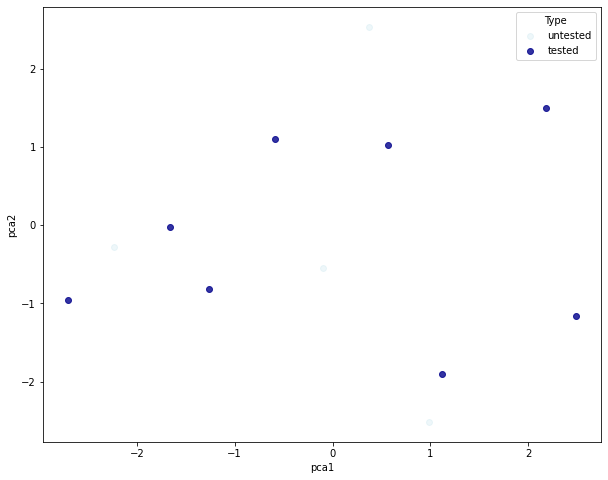

In [6]:
#perform UMAP + get basic plot output
feats = feats_scaled
pca = PCA(n_components=2)
pca.fit(feats)
pca_results = pca.transform(feats)

pca_score = pca.explained_variance_ratio_
pca_values = pca.singular_values_
V = pca.components_

print('Total variance explained by PCs:',round(np.sum(pca.explained_variance_ratio_*100),1),'%\n')
print("Percentage of explained variance per principal component")
for i,j in enumerate(pca_score):
    print(f"PC{i+1}   {j*100:.1f}%")

pca_df = pd.DataFrame(pca_results, columns=['pca1', 'pca2'])
pca_df['name'] = ID
pca_df['image'] = image
pca_df['smiles'] = smiles

if typecol is not None:
    pca_df['type'] = typecol
    alpha_val_map = {'tested': 0.8, 'untested': 0.2}
    color_map = {'tested': 'darkblue', 'untested': 'lightblue'}
    
    pca_df = cf.map_alpha_by_col(pca_df, alpha_val_map, alpha=1) 
    pca_df = cf.map_color_by_col(pca_df, color_map)
    
# if you want to plot certain types before others for visualization purposes
plot_order = ['untested', 'tested'] 
plt.figure(figsize=(10, 8))
for t in plot_order:
    subset = pca_df[pca_df['type'] == t]
    plt.scatter(subset['pca1'], subset['pca2'], alpha=subset['alpha'].iloc[0], color=subset['color'].iloc[0], label=t)
plt.legend(title='Type')
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.show()

# #to plot all points at once
# plt.figure(figsize=(10, 8))
# plt.scatter(pca_df['pca1'], pca_df['pca2'], alpha=pca_df['alpha'], color=pca_df['color'])
# plt.xlabel('pca1')
# plt.ylabel('pca2')
# plt.show()

# pca_df.to_excel('pca_output_w_coordinates.xlsx')


In [11]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

xy_pca = pca_df[['pca1', 'pca2']]

knn = NearestNeighbors(n_neighbors=2)
knn.fit(xy_pca)

ligid = 'arbr141'
lig_xy = pca_df[pca_df['name'] == ligid][['pca1', 'pca2']].values
    
distances, indices =knn.kneighbors(lig_xy)
nn_coords = indices[0][1]
nn_id = pca_df.iloc[nn_coords]['name']

print(f'The nearest neighbor to {ligid} is {nn_id}')



The nearest neighbor to arbr141 is arbr151


/Users/therese/anaconda3/lib/python3.9/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but NearestNeighbors was fitted with feature names
  warnings.warn(


In [ ]:
#KNN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(pca, y_train)

# Predict on test data
y_pred = knn.predict(X_test_pca)


## UMAP

In [ ]:
#perform UMAP + get basic plot output
feats = feats_scaled
reducer = umap.UMAP( n_neighbors=20, min_dist=0.01,n_components=2,metric = 'manhattan',random_state=42)
umap_results = reducer.fit_transform(feats)

umap_df = pd.DataFrame(umap_results, columns=['UMAP1', 'UMAP2'])
umap_df['name'] = ID
umap_df['image'] = image
umap_df['smiles'] = smiles

if typecol is not None:
    umap_df['type'] = typecol
    alpha_val_map = {'tested': 0.8, 'untested': 0.2}
    color_map = {'tested': 'darkblue', 'untested': 'lightblue'}
    
    umap_df = cf.map_alpha_by_col(umap_df, alpha_val_map, alpha=1) 
    umap_df = cf.map_color_by_col(umap_df, color_map)
    
# if you want to plot certain types before others for visualization purposes
plot_order = ['untested', 'tested'] 
plt.figure(figsize=(10, 8))
for t in plot_order:
    subset = umap_df[umap_df['type'] == t]
    plt.scatter(subset['UMAP1'], subset['UMAP2'], alpha=subset['alpha'].iloc[0], color=subset['color'].iloc[0], label=t)
plt.legend(title='Type')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()

# #to plot all points at once
# plt.figure(figsize=(10, 8))
# plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], alpha=umap_df['alpha'], color=umap_df['color'])
# plt.xlabel('UMAP1')
# plt.ylabel('UMAP2')
# plt.show()

# umap_df.to_excel('umap_output_w_coordinates.xlsx')


In [ ]:
#interactive plot
int_plt = cf.scatter_plot(umap_df, x='UMAP1', y='UMAP2', svgs='image', hover_list=['name'], size=10, 
                       alpha=0.8 )
int_plt

## TSNE

In [ ]:
tsne = TSNE(n_components=2, perplexity=20, learning_rate=300, metric='manhattan', 
            init='random', random_state=42, )
tsne_results = tsne.fit_transform(feats_scaled)

tsne_df = pd.DataFrame(tsne_results, columns=['TSNE1', 'TSNE2'])
tsne_df['name'] = ID
tsne_df['type'] = typecol
tsne_df['image'] = image
tsne_df['smiles'] = smiles

alpha_mapping = {
    'tested': 0.8,
    'untested': 0.2,
}
tsne_df['alpha'] = tsne_df['type'].map(alpha_mapping)

color_mapping = {
    'tested': 'darkblue',
    'untested': 'lightblue',
}
tsne_df['color'] = tsne_df['type'].map(color_mapping)
plot_order = ['untested', 'tested'] 

plt.figure(figsize=(10, 8))
for t in plot_order:
    subset = tsne_df[tsne_df['type'] == t]
    plt.scatter(subset['TSNE1'], subset['TSNE2'], alpha=subset['alpha'].iloc[0], color=subset['color'].iloc[0], label=t)

# Clustering Techniques

In [8]:
clustering_data = pca_results # or from TSNE, or your full feature sets
df = pca_df

## K-Means Clustering

In [ ]:
# see silhouette scores for different numbers of clusters
# ideal plot: clusters have above average silhouette scores, size of the silhouette plots are similar 
# and thickness of the plot for each cluster is uniform
# higher score (up to 1) indicates better clustering

n_clusters_range = range(2, 10) 
for k in n_clusters_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(clustering_data)
    
    silhouette_avg = silhouette_score(clustering_data, kmeans.fit_predict(clustering_data))
    
    fig, ax = plt.subplots(figsize=(8, 6))
    visualizer = SilhouetteVisualizer(kmeans, colors='yellowbrick', ax=ax)
    visualizer.fit(clustering_data)
    
    plt.xlabel('Silhouette Score')
    plt.title(f'Silhouette Score for {k} Clusters: {silhouette_avg:.2f}')
    plt.show()
    

In [ ]:
# perform the clustering - not appropriate for use with UMAP!!!
kmeans = KMeans(n_clusters=7, random_state=10)  # Adjust n_clusters based on your data
clusters = kmeans.fit_predict(clustering_data)
df['cluster'] = clusters

#plot simply png
plt.figure(figsize=(8, 6))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='cluster', palette='viridis', data=df[df['type'] == 'untested'],
                legend=False, markers='o', sizes=20, edgecolor=None, alpha=0.5)
sns.scatterplot(x='UMAP1', y='UMAP2',  color='black', data=df[df['type'] == 'tested'],
                legend=False, markers='*', sizes=50, edgecolor=None, alpha=1.0)
plt.title('KMeans Clustering of TSNE Reduced Space')
plt.show()

#plot interactive HTML plot
int_plt = cf.scatter_plot(df, x='UMAP1', y='UMAP2', svgs='image', hover_list=['name'], groupby='cluster', 
                   color='Viridis', alpha=0.8, size=10)
int_plt
# hv.extension('bokeh')
# hv.save(int_plt, 'kmeans_clust_prim_ami_results.html', backend='bokeh', resources=INLINE)




## HDBSCAN Clustering

In [ ]:
hv.extension('plotly')

clusterer = hdbscan.HDBSCAN(min_cluster_size=20, min_samples=50, metric='manhattan')
cluster_labels = clusterer.fit_predict(clustering_data)
clustered = (cluster_labels >= 0)

df['cluster'] = cluster_labels
# df.to_excel ('./undersampled_model/hdbscan_clusters_prim_amine.xlsx', index = False)

print("Fraction of points clustered:",np.sum(clustered) / df.shape[0])
plt.figure(figsize=(10, 8))
palette = sns.color_palette('viridis', as_cmap=True)
cluster_palette = {label: palette(i) for i, label in enumerate(set(cluster_labels) - {-1})}
cluster_palette[-1] = (0.5, 0.5, 0.5)  # Grey color for noise

sns.scatterplot(x='UMAP1', y='UMAP2', hue='cluster', palette='viridis', data=df)
# sns.scatterplot(x='TSNE1', y='TSNE2', hue='cluster', palette='viridis', data=df)
plt.show()

## DBSCAN Clustering

In [ ]:
dbscan = DBSCAN(metric='manhattan', min_samples=12)  # Adjust parameters based on your data
clusters = dbscan.fit_predict(clustering_data)
df['cluster'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(x='UMAP1', y='UMAP2', hue='cluster', palette='tab10', data=df, legend="full")
plt.show()

## GMM Clustering

In [ ]:
#perform the clustering with GMM + plot (not interactive)
X = df[['UMAP1', 'UMAP2']].values
n = 12

gmm = GaussianMixture(n_components=n, random_state=42, covariance_type='full') 
gmm.fit(X)
labels = gmm.predict(X)
soft_labels = gmm.predict_proba(X)
soft_labels_df = pd.DataFrame(soft_labels, columns=[f'prob_belonging_to_cluster_{i}' for i in range(n)])
df['cluster'] = labels
df = pd.concat([df, soft_labels_df], axis=1)

#plot png 
sns.scatterplot(x='UMAP1', y='UMAP2', hue='cluster', palette='viridis', data=df[df['type'] == 'untested'],
                legend=False, markers='o', sizes=20, edgecolor=None, alpha=0.5)
sns.scatterplot(x='UMAP1', y='UMAP2',  color='black', data=df[df['type'] == 'tested'],
                legend=False, markers='*', sizes=50, edgecolor=None, alpha=1.0)

#plot interactive HTML plot
int_plt = cf.scatter_plot(df, x='UMAP1', y='UMAP2', svgs='image', hover_list=['name'], groupby='cluster', 
                   color='Viridis', alpha=0.8, size=10)
int_plt
# hv.extension('bokeh')
# hv.save(int_plt, 'kmeans_clust_prim_ami_results.html', backend='bokeh', resources=INLINE)

In [ ]:
df

In [ ]:
plt = cf.scatter_plot(df, x='UMAP1', y='UMAP2', svgs='image', hover_list=['name'], groupby='cluster', 
                   color='Viridis', alpha=1.0, size=10)
plt

#if you want to save the interactive plot as an HTML
hv.extension('bokeh')
hv.save(plt, 'interactive_plot.html', backend='bokeh', resources=INLINE)

In [ ]:
# see how many components are reasonable 
n_components = np.arange(1, 15)
models = [GaussianMixture(n, covariance_type= 'full', random_state=0).fit(X)
          for n in n_components]

plt.plot(n_components, [m.bic(X) for m in models], label='BIC')
plt.plot(n_components, [m.aic(X) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components');

## BIRCH Algorithm Clustering

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

birch_model = Birch(threshold=0.8, n_clusters=5)
birch_model.fit(clustering_data)
labels = birch_model.predict(clustering_data)
df['Cluster'] = labels

plt.figure(figsize=(10, 6))
# sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster', data=df, palette='viridis', s=40)
sns.scatterplot(x='UMAP1', y='UMAP2', hue='Cluster', data=df, palette='viridis', s=40)
plt.title('BIRCH Clustering on 2D t-SNE Reduced Data')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(title='Cluster')
plt.show()


In [ ]:
n_clusters_range = range(2, 20) 
inertia_values = []
silhouette_scores = []

for n_clusters in n_clusters_range:
    birch_model = Birch(n_clusters=n_clusters, threshold=.5)
    birch_model.fit(clustering_data)
    labels = birch_model.predict(clustering_data)
    
    # Calculate the inertia (sum of squared distances to the closest centroid)
    # Note: BIRCH doesn't have an explicit inertia attribute, but we can calculate it manually
    cluster_centers = birch_model.subcluster_centers_
    inertia = np.sum([np.min(np.sum((point - cluster_centers)**2, axis=1)) for point in clustering_data])
    inertia_values.append(inertia)
    
    # Calculate the silhouette score
    silhouette_avg = silhouette_score(clustering_data, labels)
    silhouette_scores.append(silhouette_avg)
    

# Silhouette Score Plot
plt.subplot(1, 2, 2)
plt.plot(n_clusters_range, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (n_clusters)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal n_clusters')

plt.show()

